# PIPELINE PARALELO DE PROCESSAMENTO DE IMAGENS COM MULTIPROCESSING

INSTITUTO FEDERAL DE MINAS GERIAS Departamento de Engenharia e Computação

Aluno: Euler Gomes


# 1. Preparação do ambiente

In [41]:
from IPython.display import display, HTML

display(HTML("<style>.container {widht: 100% !important;}</style>"))

## 1.1. Importação das bibliotecas

In [42]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
import shutil
import subprocess
import sys
import os
import kagglehub
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary
import pygame
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

## 1.2. Exporta requirements (Fase 1)

In [43]:
def exporta_requirements():
    try:
        result = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                                capture_output=True,
                                text=True,
                                check=True)
        with open('requirements.txt', 'w') as f:
            f.write(result.stdout)
        print('requirements.txt gerado com sucesso.')
    except subprocess.CalledProcessError as e:
        print('erro:', e)


exporta_requirements()

requirements.txt gerado com sucesso.


## 1.3. Checagem de GPU

In [44]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA não disponivel.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 91501
Device: NVIDIA GeForce RTX 5070
Device: cuda


# 2. Carregar Dataset

## 2.1. Baixar dataset

In [45]:
baixar_dataset = False

if baixar_dataset:
    path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

    dest = Path("../parallel_loading/data/raw")
    dest.mkdir(parents=True, exist_ok=True)

    os.system(f"ln -s {path}/* {dest}")

## 2.2. Juntar dataset

In [46]:
img_data1 = "/parallel_loading/data/raw/HAM10000_images_part_1"
img_data2 = "/parallel_loading/data/raw/HAM10000_images_part_2"
dest = "data/raw/images"

os.makedirs(dest, exist_ok=True)

juntar_data = False

if juntar_data:
    for folder in [img_data1, img_data2]:
        if os.path.exists(folder):
            for file in os.listdir(folder):
                shutil.copy(os.path.join(folder, file), dest)
        else:
            print(
                f"Warning: Folder not found: {folder}. Skipping. Please ensure the dataset was downloaded and linked correctly in the previous step.")

## 2.3. Dividir dataset

In [47]:
df = pd.read_csv('data/raw/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [48]:
grouped = df.groupby('lesion_id').first().reset_index()
grouped.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000000,ISIC_0028498,nv,histo,60.0,male,back
1,HAM_0000001,ISIC_0027859,bkl,histo,70.0,female,face
2,HAM_0000002,ISIC_0033848,mel,histo,65.0,female,lower extremity
3,HAM_0000003,ISIC_0027886,nv,follow_up,55.0,male,trunk
4,HAM_0000004,ISIC_0024645,nv,follow_up,40.0,female,back


In [49]:
train_df, temp_df = train_test_split(
    grouped,
    test_size=0.3,
    stratify=grouped['dx'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['dx'],
    random_state=42
)

In [50]:
train = df[df['lesion_id'].isin(train_df['lesion_id'])]
val = df[df['lesion_id'].isin(val_df['lesion_id'])]
test = df[df['lesion_id'].isin(test_df['lesion_id'])]

In [51]:
def organize(df, split_name):
    for _, row in df.iterrows():
        label = row['dx']
        img_id = row['image_id'] + ".jpg"

        img_path = f"data/raw/images/{img_id}"
        dest_path = f"data/split/{split_name}/{label}/{img_id}"

        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        shutil.copy(img_path, dest_path)


organize(train, "train")
organize(val, "val")
organize(test, "test")

## 2.4. Exploração do dataset

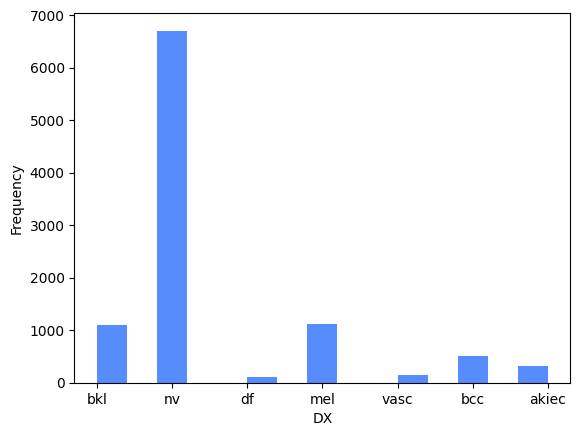

In [52]:
plt.hist(df["dx"], bins=15)
plt.xlabel("DX")
plt.ylabel("Frequency")
plt.show()

In [53]:
df.isna().sum().sort_values(ascending=False)

age             57
image_id         0
lesion_id        0
dx               0
dx_type          0
sex              0
localization     0
dtype: int64

# 3. Pré Processamento

## 3.1. Transformações

In [54]:
augment_classes = ['bkl', 'df', 'mel', 'vasc', 'bcc', 'akiec']

In [55]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [56]:
train_dataset = ImageFolder("data/split/train", transform=transform)
val_dataset = ImageFolder("data/split/val", transform=transform)
test_dataset = ImageFolder("data/split/test", transform=transform)

## 3.2. Arquitetura da CNN

In [57]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7, input_channels=3):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # Para entrada 128x128, após 3 pools (2^3 = 8), dimensão final = 128/8 = 16
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 3.3. Data loaders (Fase 2)

In [58]:
learning_rate = 0.001
max_epochs = 5

batch_size = 64
num_worker = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_worker, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_worker, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_worker, pin_memory=True)

model = CNNModel().to(device)

count = torch.tensor([52, 71, 167, 20, 167, 1004, 21], dtype=torch.float)
total = count.sum()
num_classes = len(count)

weights = total / (num_classes * count)

weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [59]:
summary(model)

Layer (type:depth-idx)                   Param #
CNNModel                                 --
├─Conv2d: 1-1                            896
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            18,496
├─Conv2d: 1-4                            73,856
├─Linear: 1-5                            8,388,864
├─Linear: 1-6                            1,799
├─Dropout: 1-7                           --
Total params: 8,483,911
Trainable params: 8,483,911
Non-trainable params: 0

## 3.4. Treinamento do modelo

In [60]:
total_start_time = time.time()

for epoch in range(max_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    epoch_times = []
    total_images = 0
    for images, labels in train_loader:
        total_images += images.size(0)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        end_time = time.time()
        epoch_time = end_time - start_time
        epoch_times.append(epoch_time)

    print(f"Epoch {epoch + 1} - Train loss: {loss:.4f} - Epoch time: {np.mean(epoch_times):.2f}s")

total_time = time.time() - total_start_time
throughput = (len(train_loader.dataset) * max_epochs) / total_time

print(f"Total time: {total_time} - Throughput: {throughput:.2f} images/s")

Epoch 1 - Train loss: 1.5631 - Epoch time: 3.16s
Epoch 2 - Train loss: 1.6685 - Epoch time: 3.30s
Epoch 3 - Train loss: 1.0265 - Epoch time: 4.19s
Epoch 4 - Train loss: 1.6975 - Epoch time: 3.14s
Epoch 5 - Train loss: 1.0007 - Epoch time: 3.13s
Total time: 31.720197677612305 - Throughput: 1100.40 images/s


In [61]:
pygame.mixer.init()
success_audio = 'support_files/mario_coin.mp3'
pygame.mixer.music.load(success_audio)
pygame.mixer.music.play()

while pygame.mixer.music.get_busy():
    continue

print('Success!')

Success!


## 3.5. Validação do modelo

In [62]:
model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    val_loss = 0
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()
        pred = torch.argmax(outputs, dim=1)
        correct += torch.sum(pred == labels).sum().item()
        total += labels.size(0)

val_acc = correct / total

print(f"Validation loss: {val_loss / len(val_loader):.4f}")
print(f'Validation accuracy: {val_acc:.4f}')

Validation loss: 1.2044
Validation accuracy: 0.5091


## 3.6. Teste do modelo

In [63]:
y_hat = []
y_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        pred = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_hat.extend(pred.cpu().numpy())

print(*y_hat)

2 0 4 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 2 0 1 4 0 1 1 4 0 0 3 1 0 0 0 0 1 1 1 0 0 0 0 0 1 2 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 3 0 1 1 0 2 1 6 1 1 1 5 1 6 1 1 0 1 4 1 1 1 0 1 1 1 1 4 1 1 1 3 1 1 0 4 1 1 0 1 1 1 1 0 1 2 0 2 1 1 2 1 1 1 1 2 2 0 0 1 0 2 4 4 2 4 1 4 1 1 2 1 5 1 1 4 1 2 1 2 1 6 0 4 1 4 5 1 2 4 2 1 2 4 1 0 0 2 1 1 5 0 2 4 2 1 4 2 1 1 1 0 1 2 4 2 0 1 2 2 5 2 1 1 1 2 2 2 2 2 0 2 2 2 1 1 1 1 4 6 2 4 2 1 4 1 1 1 1 2 4 1 5 6 4 5 1 4 1 2 1 1 1 1 5 2 2 0 1 1 4 2 2 1 2 2 2 2 2 1 1 3 1 2 4 4 4 0 2 4 2 4 6 5 4 2 2 2 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 1 2 2 2 4 4 0 0 4 4 3 0 1 1 4 1 3 1 1 1 0 1 1 1 1 1 4 2 2 1 5 1 5 0 4 1 4 4 4 5 1 5 4 1 4 0 0 4 0 4 5 2 4 4 2 4 4 4 5 1 4 0 2 4 4 2 4 4 4 4 0 4 5 1 4 4 4 4 4 4 4 1 2 4 1 0 1 0 4 5 4 5 1 5 5 5 1 4 2 0 0 0 4 2 0 4 2 1 4 4 4 0 5 2 0 2 4 5 4 1 4 4 2 1 4 4 4 4 4 4 4 5 4 4 4 4 4 1 4 4 4 5 4 0 4 4 4 4 4 4 5 4 4 2 4 6 4 4 5 4 4 4 2 4 4 4 4 4 4 4 4 6 4 4 4 4 4 6 4 4 4 6 4 4 4 4 4 4 4 4 4 4 0 4 4 2 4 5 5 5 5 5 2 4 4 0 3 5 5 5 4 3 5 5 5 5 5 5 5 5 

# 4. Avaliação

In [64]:
print(classification_report(
    y_true,
    y_hat,
    zero_division=0,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

       akiec       0.18      0.40      0.25        52
         bcc       0.20      0.69      0.30        71
         bkl       0.42      0.29      0.34       167
          df       0.07      0.10      0.09        20
         mel       0.26      0.60      0.36       167
          nv       0.95      0.54      0.69      1004
        vasc       0.40      0.81      0.53        21

    accuracy                           0.52      1502
   macro avg       0.35      0.49      0.37      1502
weighted avg       0.73      0.52      0.57      1502



## 4.1. Matriz de confusão

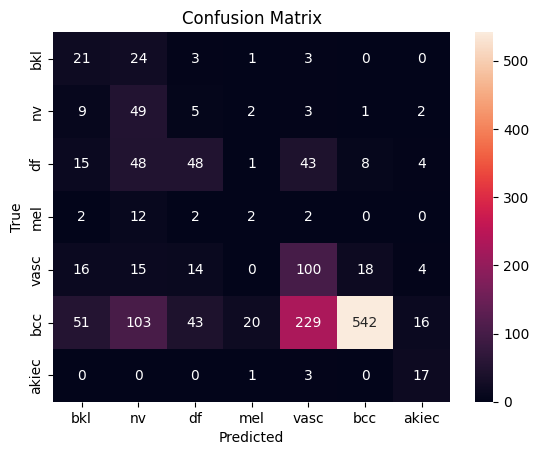

In [65]:
cm = confusion_matrix(y_true, y_hat)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=df['dx'].unique(),
    yticklabels=df['dx'].unique(),
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 5. Benchmarks

## 5.1. Variação do Número de Workers

In [66]:
batch_size_fixed = 64
num_workers_list = [0, 2, 4, 6, 8]
results_workers = []

for workers in num_workers_list:
    print(f"\nnum_workers = {workers}")

    workers_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_fixed,
        shuffle=True,
        num_workers=workers,
        pin_memory=True
    )

    model = CNNModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    total_start_time = time.time()
    epoch_durations = []

    for epoch in range(max_epochs):
        start_time = time.time()
        model.train()

        running_corrects = 0
        total_samples = 0

        for images, labels in workers_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

        epoch_time = time.time() - start_time
        epoch_durations.append(epoch_time)

        epoch_acc = running_corrects.double() / total_samples
        print(f"Epoch {epoch + 1} - Tempo: {epoch_time:.2f}s - Acc: {epoch_acc:.4f}")

    total_time_spent = time.time() - total_start_time
    throughput = (len(workers_loader.dataset) * max_epochs) / total_time_spent
    final_accuracy = epoch_acc

    results_workers.append({
        'workers': workers,
        'avg_epoch_time': np.mean(epoch_durations),
        'total_time': total_time_spent,
        'accuracy': final_accuracy.item(),
        'throughput': throughput
    })

    print(f"RESULTADO FINAL (workers={workers}):")
    print(f" - Tempo Total Gasto: {total_time_spent:.2f}s")
    print(f" - Acurácia Final: {final_accuracy:.4f}")
    print(f" - Throughput: {throughput:.2f} images/s")


--- Iniciando teste com num_workers = 0 ---
Epoch 1 - Tempo: 20.64s - Acc: 0.6668
Epoch 2 - Tempo: 20.64s - Acc: 0.6917
Epoch 3 - Tempo: 20.67s - Acc: 0.7115
Epoch 4 - Tempo: 20.59s - Acc: 0.7284
Epoch 5 - Tempo: 20.60s - Acc: 0.7427
RESULTADO FINAL (workers=0):
 - Tempo Total Gasto: 103.15s
 - Acurácia Final: 0.7427
 - Throughput: 338.41 images/s

--- Iniciando teste com num_workers = 2 ---
Epoch 1 - Tempo: 10.93s - Acc: 0.6768
Epoch 2 - Tempo: 10.83s - Acc: 0.6952
Epoch 3 - Tempo: 10.95s - Acc: 0.7099
Epoch 4 - Tempo: 11.14s - Acc: 0.7347
Epoch 5 - Tempo: 11.15s - Acc: 0.7443
RESULTADO FINAL (workers=2):
 - Tempo Total Gasto: 55.00s
 - Acurácia Final: 0.7443
 - Throughput: 634.58 images/s

--- Iniciando teste com num_workers = 4 ---
Epoch 1 - Tempo: 6.10s - Acc: 0.6734
Epoch 2 - Tempo: 6.00s - Acc: 0.7033
Epoch 3 - Tempo: 6.13s - Acc: 0.7243
Epoch 4 - Tempo: 6.18s - Acc: 0.7367
Epoch 5 - Tempo: 6.12s - Acc: 0.7460
RESULTADO FINAL (workers=4):
 - Tempo Total Gasto: 30.54s
 - Acurácia

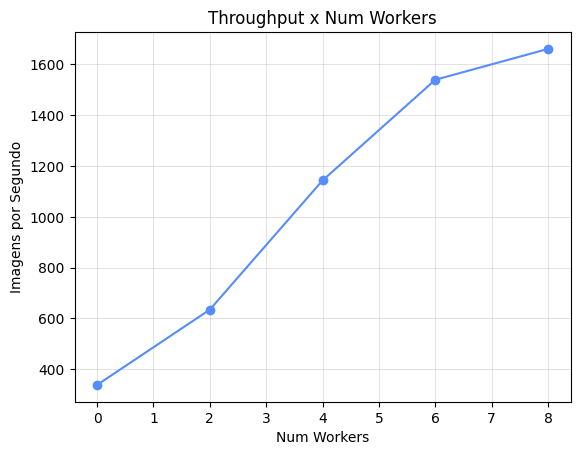

In [67]:
df = pd.DataFrame(results_workers)

plt.plot(df['workers'], df['throughput'], marker='o')
plt.title('Throughput x Num Workers')
plt.xlabel('Num Workers')
plt.ylabel('Imagens por Segundo')
plt.grid(True)
plt.show()

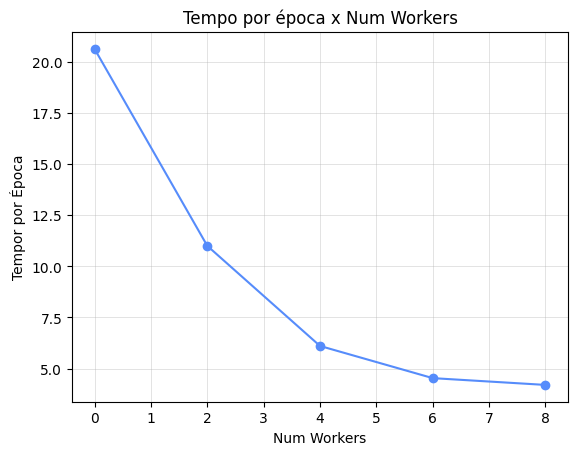

In [71]:
df = pd.DataFrame(results_workers)

plt.plot(df['workers'], df['avg_epoch_time'], marker='o')
plt.title('Tempo por época x Num Workers')
plt.xlabel('Num Workers')
plt.ylabel('Tempor por Época')
plt.grid(True)
plt.show()

## 5.2. Variação do Batch Size

In [69]:
batch_size_list = [32, 64, 128, 256]
num_workers_fixed = 4
results_batches = []

for batches in batch_size_list:
    print(f"\nBatch Size = {batches}")

    batches_loader = DataLoader(
        train_dataset,
        batch_size=batches,
        shuffle=True,
        num_workers=num_workers_fixed,
        pin_memory=True
    )

    model = CNNModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    total_start_time = time.time()
    epoch_durations = []

    for epoch in range(max_epochs):
        start_time = time.time()
        model.train()

        running_corrects = 0
        total_samples = 0

        for images, labels in batches_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Cálculo de acertos para a acurácia de treinamento
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

        epoch_time = time.time() - start_time
        epoch_durations.append(epoch_time)

        epoch_acc = running_corrects.double() / total_samples
        print(f"Epoch {epoch + 1} - Tempo: {epoch_time:.2f}s - Acc: {epoch_acc:.4f}")

    total_time_spent = time.time() - total_start_time
    throughput = (len(batches_loader.dataset) * max_epochs) / total_time_spent

    results_batches.append({
        'batch_size': batches,
        'avg_epoch_time': np.mean(epoch_durations),
        'total_time': total_time_spent,
        'accuracy': epoch_acc.item(),
        'throughput': throughput
    })

    print(f"RESULTADO FINAL (Batch Size {batches}):")
    print(f" - Tempo Total Gasto: {total_time_spent:.2f}s")
    print(f" - Acurácia Final: {epoch_acc:.4f}")
    print(f" - Throughput: {throughput:.2f} imagens/s")


--- Iniciando benchmark: Batch Size = 32 ---
Epoch 1 - Tempo: 6.21s - Acc: 0.6747
Epoch 2 - Tempo: 6.25s - Acc: 0.7000
Epoch 3 - Tempo: 6.12s - Acc: 0.7191
Epoch 4 - Tempo: 6.25s - Acc: 0.7277
Epoch 5 - Tempo: 6.04s - Acc: 0.7457
RESULTADO FINAL (Batch Size 32):
 - Tempo Total Gasto: 30.88s
 - Acurácia Final: 0.7457
 - Throughput: 1130.36 imagens/s

--- Iniciando benchmark: Batch Size = 64 ---
Epoch 1 - Tempo: 6.60s - Acc: 0.6677
Epoch 2 - Tempo: 6.61s - Acc: 0.6909
Epoch 3 - Tempo: 6.18s - Acc: 0.7114
Epoch 4 - Tempo: 6.14s - Acc: 0.7287
Epoch 5 - Tempo: 6.21s - Acc: 0.7409
RESULTADO FINAL (Batch Size 64):
 - Tempo Total Gasto: 31.74s
 - Acurácia Final: 0.7409
 - Throughput: 1099.64 imagens/s

--- Iniciando benchmark: Batch Size = 128 ---
Epoch 1 - Tempo: 6.26s - Acc: 0.6624
Epoch 2 - Tempo: 6.49s - Acc: 0.7003
Epoch 3 - Tempo: 6.23s - Acc: 0.7157
Epoch 4 - Tempo: 6.17s - Acc: 0.7320
Epoch 5 - Tempo: 6.02s - Acc: 0.7455
RESULTADO FINAL (Batch Size 128):
 - Tempo Total Gasto: 31.17s
 

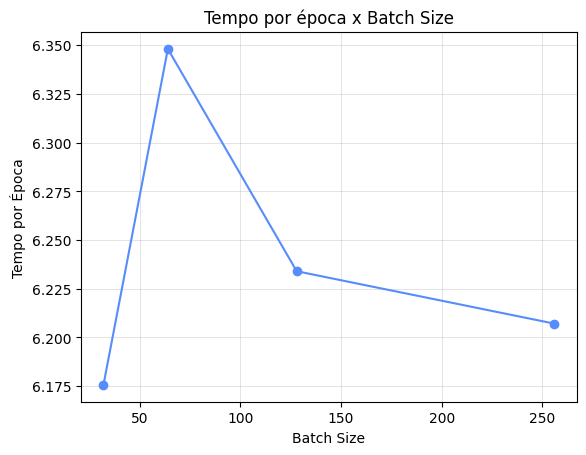

In [70]:
df = pd.DataFrame(results_batches)

plt.plot(df['batch_size'], df['avg_epoch_time'], marker='o')
plt.title('Tempo por época x Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Tempo por Época')
plt.grid(True)
plt.show()